Two component GPE with dissiaption simulator

In [4]:
import numpy as np

def simulate_steady_state(Omega_val, Delta_val, omega_val, t_relax, dt, T_obs):

    """
    Omega = 2 pi (1e1- 1e4) Hz
    Delta = -50-50 kHz
    omega = 2 pi (50-500) Hz
    g = 4 pi hbar^2 a_s / m, where a_s is the s-wave scattering length
    """

    # ==========================================
    # System Parameters & Grid Setup
    # ==========================================
    hbar = 1.0 # 6.62607015e-34  # Planck's constant
    m = 1.0 # 1.44e-25  # Mass of the particle (e.g., Rubidium atom)
    gamma = 0.1 # 1e5 # Hz

    # Interactions
    g_ee = g_gg = g_eg = 1.0 # 4 * np.pi * hbar**2 * 100 * 5.29e-11 / m  # J m^3
    
    # Grid parameters
    L = 10.0 #100e-6         # Domain size (m)
    N_grid = 128      # Number of spatial grid points
    dx = L / N_grid
    x = np.linspace(-L/2, L/2 - dx, N_grid)
    # Momentum space grid for spectral derivatives
    k = np.fft.fftfreq(N_grid, d=dx) * 2 * np.pi
    
    # Time parameters
    total_time = t_relax + T_obs
    num_steps = int(total_time / dt)
    relax_steps = int(t_relax / dt)
    
    # Physical parameters
    Omega = np.ones(N_grid) * Omega_val + 0j # Coherent drive
    Delta = np.ones(N_grid) * Delta_val + 0j # Detuning

    # Potentials
    V_e = 0.5 * omega_val * (1.0 * x)**2
    V_g = 0.5 * omega_val * (1.0 * x)**2
    
    # ==========================================
    # Initialization
    # ==========================================
    # Start with a simple normalized Gaussian in the ground state
    psi_g = np.exp(-x**2 / 2.0) + 0j
    psi_e = np.zeros(N_grid, dtype=complex)
    
    norm = np.sum(np.abs(psi_e)**2 + np.abs(psi_g)**2) * dx
    psi_g /= np.sqrt(norm)
    
    # Density matrix accumulators for ergodic time-averaging
    rho_ee_ss = np.zeros(N_grid, dtype=complex)
    rho_gg_ss = np.zeros(N_grid, dtype=complex)
    rho_eg_ss = np.zeros(N_grid, dtype=complex)
    time_steps_averaged = 0
    
    # ==========================================
    # Evolution Functions
    # ==========================================
    def get_derivatives(pe, pg):
        """Calculates the right-hand side of the non-Hermitian GPE."""
        # Kinetic terms via FFT
        lap_e = np.fft.ifft(-k**2 * np.fft.fft(pe))
        lap_g = np.fft.ifft(-k**2 * np.fft.fft(pg))
        
        # Effective Hamiltonians
        H_e_pe = -(hbar**2 / (2*m)) * lap_e + V_e * pe + g_ee * np.abs(pe)**2 * pe + g_eg * np.abs(pg)**2 * pe
        H_g_pg = -(hbar**2 / (2*m)) * lap_g + V_g * pg + g_gg * np.abs(pg)**2 * pg + g_eg * np.abs(pe)**2 * pg
        
        # Coupled equations (including non-Hermitian loss on ground state)
        dpe_dt = (-1j / hbar) * (H_e_pe + Delta * pe + Omega * pg)
        dpg_dt = (-1j / hbar) * (H_g_pg + np.conj(Omega) * pe) - (gamma / 2) * pg
        
        return dpe_dt, dpg_dt

    # ==========================================
    # Main Integration Loop
    # ==========================================
    for step in range(num_steps):
        
        # Calculate jump probability based on current state
        norm_g = np.sum(np.abs(psi_g)**2) * dx
        dp = dt * gamma * norm_g
        
        # Generate random number for Monte Carlo jump
        eta = np.random.rand()
        
        if eta < dp:
            # Quantum Jump applies \sigma^+ (transfers psi_g to psi_e and empties ground state)
            psi_e = psi_g / np.sqrt(norm_g)
            psi_g = np.zeros(N_grid, dtype=complex)
            
        else:
            # Deterministic evolution using RK4
            k1_e, k1_g = get_derivatives(psi_e, psi_g)
            k2_e, k2_g = get_derivatives(psi_e + 0.5*dt*k1_e, psi_g + 0.5*dt*k1_g)
            k3_e, k3_g = get_derivatives(psi_e + 0.5*dt*k2_e, psi_g + 0.5*dt*k2_g)
            k4_e, k4_g = get_derivatives(psi_e + dt*k3_e, psi_g + dt*k3_g)
            
            psi_e_new = psi_e + (dt/6.0) * (k1_e + 2*k2_e + 2*k3_e + k4_e)
            psi_g_new = psi_g + (dt/6.0) * (k1_g + 2*k2_g + 2*k3_g + k4_g)
            
            # Renormalize to account for non-Hermitian norm loss
            renorm_factor = 1.0 / np.sqrt(1.0 - dp)
            psi_e = psi_e_new * renorm_factor
            psi_g = psi_g_new * renorm_factor

        # ==========================================
        # Ergodic Steady State Averaging
        # ==========================================
        if step >= relax_steps:
            rho_ee_ss += psi_e * np.conj(psi_e)
            rho_gg_ss += psi_g * np.conj(psi_g)
            rho_eg_ss += psi_e * np.conj(psi_g)
            time_steps_averaged += 1

    # Finalize time averages
    rho_ee_ss /= time_steps_averaged
    rho_gg_ss /= time_steps_averaged
    rho_eg_ss /= time_steps_averaged

    return x, rho_ee_ss, rho_gg_ss, rho_eg_ss

In [5]:
# Execute the simulation
x_grid, rho_ee, rho_gg, rho_eg = simulate_steady_state(1.0, 0.0, 1.0, t_relax=5.0, dt=1e-4, T_obs=10.0)

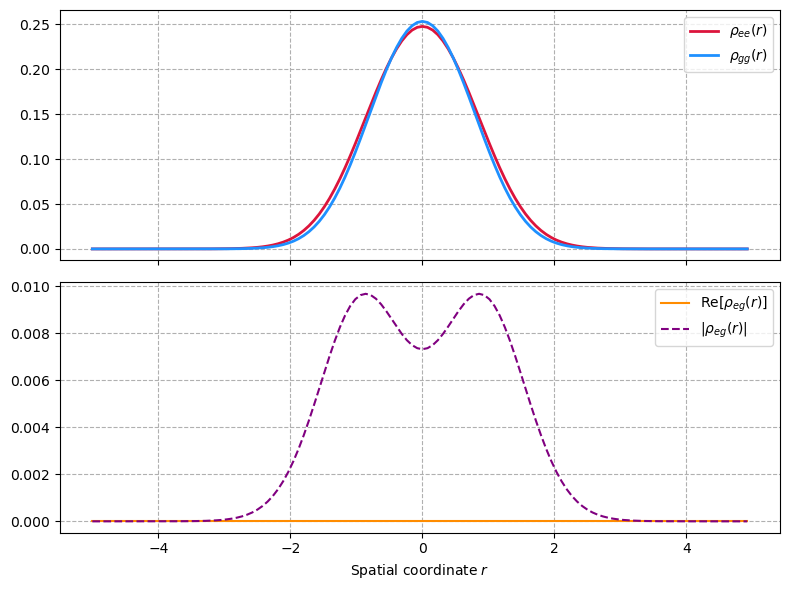

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Density plot
ax1.plot(x_grid, rho_ee.real, label=r'$\rho_{ee}(r)$', color='crimson', lw=2)
ax1.plot(x_grid, rho_gg.real, label=r'$\rho_{gg}(r)$', color='dodgerblue', lw=2)
ax1.grid(True, linestyle='--')
ax1.legend()

# Coherence plot
ax2.plot(x_grid, rho_eg.real, label=r'$\mathrm{Re}[\rho_{eg}(r)]$', color='darkorange', lw=1.5)
ax2.plot(x_grid, np.abs(rho_eg), label=r'$|\rho_{eg}(r)|$', color='purple', lw=1.5, linestyle='--')
ax2.set_xlabel('Spatial coordinate $r$')
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()

The above steady state can be used to compute $Q_{rev}$. Dissipative heat cannot be computed this way, since we dont know the dynamics generator.

Simulate dynamics with time dependant control parameters

In [7]:
import numpy as np
from joblib import Parallel, delayed

def _single_trajectory(time, dt, num_steps, N_grid, dx, x, k, hbar, m, gamma, g_ee, g_gg, g_eg, Omega_func, Delta_func, omega_func):
    """Worker function to simulate a single quantum trajectory."""
    # Initialization
    psi_g = np.exp(-x**2 / 2.0) + 0j
    psi_e = np.zeros(N_grid, dtype=complex)
    
    norm = np.sum(np.abs(psi_e)**2 + np.abs(psi_g)**2) * dx
    psi_g /= np.sqrt(norm)
    
    # Track trajectory history
    psi_e_history = np.zeros((num_steps, N_grid), dtype=complex)
    psi_g_history = np.zeros((num_steps, N_grid), dtype=complex)
    
    def get_derivatives(pe, pg, Omega, Delta, V_e, V_g):
        lap_e = np.fft.ifft(-k**2 * np.fft.fft(pe))
        lap_g = np.fft.ifft(-k**2 * np.fft.fft(pg))
        
        H_e_pe = -(hbar**2 / (2*m)) * lap_e + V_e * pe + g_ee * np.abs(pe)**2 * pe + g_eg * np.abs(pg)**2 * pe
        H_g_pg = -(hbar**2 / (2*m)) * lap_g + V_g * pg + g_gg * np.abs(pg)**2 * pg + g_eg * np.abs(pe)**2 * pg
        
        dpe_dt = (-1j / hbar) * (H_e_pe + Delta * pe + Omega * pg)
        dpg_dt = (-1j / hbar) * (H_g_pg + np.conj(Omega) * pe) - (gamma / 2) * pg
        return dpe_dt, dpg_dt

    for step in range(num_steps):
        psi_e_history[step, :] = psi_e
        psi_g_history[step, :] = psi_g

        Omega = np.ones(N_grid) * Omega_func(step * dt) + 0j
        Delta = np.ones(N_grid) * Delta_func(step * dt) + 0j
        V_e = 0.5 * omega_func(step * dt) * (1.0 * x)**2
        V_g = V_e

        norm_g = np.sum(np.abs(psi_g)**2) * dx
        dp = dt * gamma * norm_g
        
        if np.random.rand() < dp:
            psi_e = psi_g / np.sqrt(norm_g)
            psi_g = np.zeros(N_grid, dtype=complex)
        else:
            k1_e, k1_g = get_derivatives(psi_e, psi_g, Omega, Delta, V_e, V_g)
            k2_e, k2_g = get_derivatives(psi_e + 0.5*dt*k1_e, psi_g + 0.5*dt*k1_g, Omega, Delta, V_e, V_g)
            k3_e, k3_g = get_derivatives(psi_e + 0.5*dt*k2_e, psi_g + 0.5*dt*k2_g, Omega, Delta, V_e, V_g)
            k4_e, k4_g = get_derivatives(psi_e + dt*k3_e, psi_g + dt*k3_g, Omega, Delta, V_e, V_g)
            
            psi_e_new = psi_e + (dt/6.0) * (k1_e + 2*k2_e + 2*k3_e + k4_e)
            psi_g_new = psi_g + (dt/6.0) * (k1_g + 2*k2_g + 2*k3_g + k4_g)
            
            renorm_factor = 1.0 / np.sqrt(1.0 - dp)
            psi_e = psi_e_new * renorm_factor
            psi_g = psi_g_new * renorm_factor

    return psi_e_history, psi_g_history


def simulate_ensemble_dynamics(time, dt, num_trajectories, Omega_func, Delta_func, omega_func, n_jobs=-1):
    """
    Simulates multiple quantum trajectories and averages them to find the 
    time-dependent density matrix elements.
    """
    # ==========================================
    # System Parameters & Grid Setup
    # ==========================================
    hbar = 1.0
    m = 1.0
    gamma = 0.1
    g_ee = g_gg = g_eg = 1.0
    
    L = 10.0
    N_grid = 128
    dx = L / N_grid
    x = np.linspace(-L/2, L/2 - dx, N_grid)
    k = np.fft.fftfreq(N_grid, d=dx) * 2 * np.pi
    num_steps = int(time / dt)
    t_history = np.linspace(0, time - dt, num_steps)

    # ==========================================
    # Parallel Trajectory Execution
    # ==========================================
    results = Parallel(n_jobs=n_jobs)(
        delayed(_single_trajectory)(
            time, dt, num_steps, N_grid, dx, x, k, hbar, m, gamma, g_ee, g_gg, g_eg, 
            Omega_func, Delta_func, omega_func
        ) for _ in range(num_trajectories)
    )

    # ==========================================
    # Density Matrix Reconstruction via Averaging
    # ==========================================
    rho_ee_history = np.zeros((num_steps, N_grid), dtype=complex)
    rho_gg_history = np.zeros((num_steps, N_grid), dtype=complex)
    rho_eg_history = np.zeros((num_steps, N_grid), dtype=complex)

    for psi_e_hist, psi_g_hist in results:
        rho_ee_history += np.abs(psi_e_hist)**2
        rho_gg_history += np.abs(psi_g_hist)**2
        rho_eg_history += psi_e_hist * np.conj(psi_g_hist)

    # Divide by total trajectories to secure the statistical average
    rho_ee_history /= num_trajectories
    rho_gg_history /= num_trajectories
    rho_eg_history /= num_trajectories

    return t_history, x, rho_ee_history, rho_gg_history, rho_eg_history

Example evolution with a circular control parameter loop at $\omega=0$ and around $\Delta \in [-1,1]$ and $\Omega \in [0.5,1.5]$

In [11]:
T = 100.0  # Period for modulation
dt = 1e-3
n_traj = 10

def Omega_func(t):
    return 1.0 + 0.5 * np.sin(2 * np.pi * t / T)  # Example: sinusoidal modulation

def Delta_func(t):
    return np.cos(2 * np.pi * t / T)

def omega_func(t):
    return 1.0

times, x, rho_ee_hist, rho_gg_hist, rho_eg_hist = simulate_ensemble_dynamics(T, dt, n_traj, Omega_func, Delta_func, omega_func)

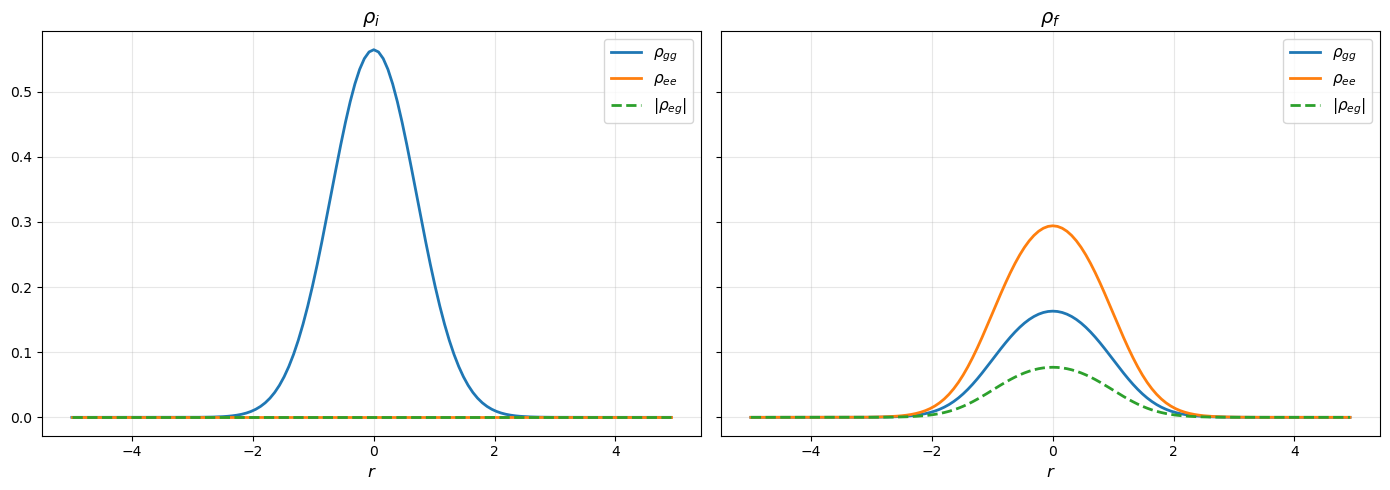

In [12]:
import matplotlib.pyplot as plt

def plot_initial_vs_final(x, rho_ee_history, rho_gg_history, rho_eg_history):
    """
    Plots the initial (t=0) and final (t=-1) profiles of the density matrix elements.
    """
    # Extract initial and final states
    rho_gg_init = np.real(rho_gg_history[0, :])
    rho_ee_init = np.real(rho_ee_history[0, :])
    rho_eg_init_abs = np.abs(rho_eg_history[0, :])

    rho_gg_final = np.real(rho_gg_history[-1, :])
    rho_ee_final = np.real(rho_ee_history[-1, :])
    rho_eg_final_abs = np.abs(rho_eg_history[-1, :])

    # Setup figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    # ------------------------------------------
    # Initial State Plot (t = 0)
    # ------------------------------------------
    axes[0].plot(x, rho_gg_init, label=r'$\rho_{gg}$', color='tab:blue', lw=2)
    axes[0].plot(x, rho_ee_init, label=r'$\rho_{ee}$', color='tab:orange', lw=2)
    axes[0].plot(x, rho_eg_init_abs, label=r'$|\rho_{eg}|$', color='tab:green', linestyle='--', lw=2)
    axes[0].set_title(r'$\rho_i$', fontsize=14)
    axes[0].set_xlabel(r'$r$', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=11)

    # ------------------------------------------
    # Final State Plot (t = Final)
    # ------------------------------------------
    axes[1].plot(x, rho_gg_final, label=r'$\rho_{gg}$', color='tab:blue', lw=2)
    axes[1].plot(x, rho_ee_final, label=r'$\rho_{ee}$', color='tab:orange', lw=2)
    axes[1].plot(x, rho_eg_final_abs, label=r'$|\rho_{eg}|$', color='tab:green', linestyle='--', lw=2)
    axes[1].set_title(r'$\rho_f$', fontsize=14)
    axes[1].set_xlabel(r'$r$', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.show()

plot_initial_vs_final(x, rho_ee_hist, rho_gg_hist, rho_eg_hist)